In [1]:
import torch
import torchvision
from torchvision import transforms,datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [3]:
dataset=datasets.ImageFolder(root="/kaggle/input/datasets/soumikrakshit/anime-faces",transform=transform)

In [5]:
dataloader=DataLoader(dataset,batch_size=32,shuffle=True,num_workers=2)


In [11]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self,z_input,feature_map=64):
        super().__init__()
        self.net=nn.Sequential(
            nn.ConvTranspose2d(z_input,feature_map*8,4,1,0),
            nn.BatchNorm2d(feature_map*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_map*8,feature_map*4,4,2,1),
            nn.BatchNorm2d(feature_map*4,affine=True),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_map*4,feature_map*2,4,2,1),
            nn.BatchNorm2d(feature_map*2,affine=True),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_map*2,feature_map,4,2,1),
            nn.BatchNorm2d(feature_map,affine=True),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_map,3,4,2,1),
            nn.Tanh()
        )
    

    def forward(self,x):
        return self.net(x)
            
class Discriminator(nn.Module):
    def __init__(self,feature_map=64):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(3,feature_map,4,2,1),
            nn.LeakyReLU(0.2,inplace=True),
            
            nn.Conv2d(feature_map,feature_map*2,4,2,1),
            nn.LeakyReLU(0.2,inplace=True),


            nn.Conv2d(feature_map*2,feature_map*4,4,2,1),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(feature_map*4,feature_map*8,4,2,1),
            nn.LeakyReLU(0.2,inplace=True),
            #lastlayer
            nn.Conv2d(feature_map*8,1,4,1,0)
        )
    
    def forward(self,x):
       return self.net(x)
            
        

    

In [12]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('InstanceNorm') != -1:
        if m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

z=100
Gen=Generator(z).to(device)
Dis=Discriminator().to(device)
Gen.apply(weights_init)
Dis.apply(weights_init)


Using device: cuda


Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
  )
)

In [9]:
lossobject=nn.BCEWithLogitsLoss() for DCGAN only

Gen_optimizer=torch.optim.Adam(Gen.parameters(),lr=0.0002,betas=(0.5,0.999))
Dis_optimizer=torch.optim.Adam(Dis.parameters(),lr=0.0002,betas=(0.5,0.999))

#fixed_noise=torch.randn(64,100,1,1,device=device)
real_labels=1.0
fake_labels=0.0


SyntaxError: invalid syntax (2398067380.py, line 1)

In [24]:
import torchvision.utils as vutils
import os
os.makedirs("dcgan_results", exist_ok=True)

num_epoch=50
G_losses=[]
D_losses=[]
img_list=[]
best_g_loss = float('inf')  # was 0, needs inf since you compare avg_g < best_g_loss
scaler=torch.amp.GradScaler('cuda')
print("Started DCGAN Training")
for i in range(num_epoch):
    g_loss_total = 0.0       # renamed: you were using g_loss_epoch but never defined it
    d_loss_total = 0.0       # renamed: same issue with d_loss_epoch
    num_batches = 0          # was never initialized
    for idx,(real_images,_) in enumerate(dataloader):
        Dis.zero_grad()
        with torch.amp.autocast('cuda'):
            real_images=real_images.to(device)
            real_output=Dis(real_images).view(-1)
            loss_real=lossobject(real_output,torch.ones_like(real_output))
        
            noise=torch.randn(real_images.size(0),100,1,1,device=device)
            fake_image=Gen(noise)
            fake_output=Dis(fake_image.detach()).view(-1)
            loss_fake=lossobject(fake_output,torch.zeros_like(fake_output))
            d_loss=loss_real+loss_fake

        scaler.scale(d_loss).backward()
        scaler.step(Dis_optimizer)

        Gen.zero_grad()
        with torch.amp.autocast('cuda'):
            output = Dis(fake_image).view(-1)
            g_loss = lossobject(output, torch.ones_like(output))
        scaler.scale(g_loss).backward()
        scaler.step(Gen_optimizer)
        scaler.update()

        g_loss_total += g_loss.item()
        d_loss_total += d_loss.item()
        num_batches += 1
    # Average losses
    avg_g = g_loss_total / num_batches
    avg_d = d_loss_total / num_batches
    G_losses.append(avg_g)
    D_losses.append(avg_d)
    print(f"Epoch [{i+1}/{num_epoch}]  Loss_D: {avg_d:.4f}  Loss_G: {avg_g:.4f}")  # was: epoch+1/num_epochs

    # Save best model
    if avg_g < best_g_loss:
        best_g_loss = avg_g
        torch.save(Gen.state_dict(), "dcgan_results/dcgan_generator_best.pth")
        torch.save(Dis.state_dict(), "dcgan_results/dcgan_discriminator_best.pth")
    
print("DCGAN Training Complete!")

        


        





Started DCGAN Training
Epoch [1/50]  Loss_D: 0.6670  Loss_G: 7.5604
Epoch [2/50]  Loss_D: 0.4431  Loss_G: 6.1738
Epoch [3/50]  Loss_D: 0.3982  Loss_G: 5.8186
Epoch [4/50]  Loss_D: 0.4037  Loss_G: 5.3980
Epoch [5/50]  Loss_D: 0.3936  Loss_G: 5.2525
Epoch [6/50]  Loss_D: 0.3502  Loss_G: 5.1349
Epoch [7/50]  Loss_D: 0.3299  Loss_G: 5.2254
Epoch [8/50]  Loss_D: 0.2980  Loss_G: 5.0901
Epoch [9/50]  Loss_D: 0.3046  Loss_G: 4.9861
Epoch [10/50]  Loss_D: 0.3078  Loss_G: 5.1614
Epoch [11/50]  Loss_D: 0.2321  Loss_G: 5.0708
Epoch [12/50]  Loss_D: 0.2927  Loss_G: 5.2004
Epoch [13/50]  Loss_D: 0.2646  Loss_G: 5.1704
Epoch [14/50]  Loss_D: 0.2517  Loss_G: 5.2936
Epoch [15/50]  Loss_D: 0.2215  Loss_G: 5.2704
Epoch [16/50]  Loss_D: 0.2175  Loss_G: 5.3948
Epoch [17/50]  Loss_D: 0.1964  Loss_G: 5.5431
Epoch [18/50]  Loss_D: 0.1224  Loss_G: 5.6641
Epoch [19/50]  Loss_D: 0.2381  Loss_G: 5.7067
Epoch [20/50]  Loss_D: 0.1840  Loss_G: 5.8853
Epoch [21/50]  Loss_D: 0.1702  Loss_G: 5.8130
Epoch [22/50]  Loss_

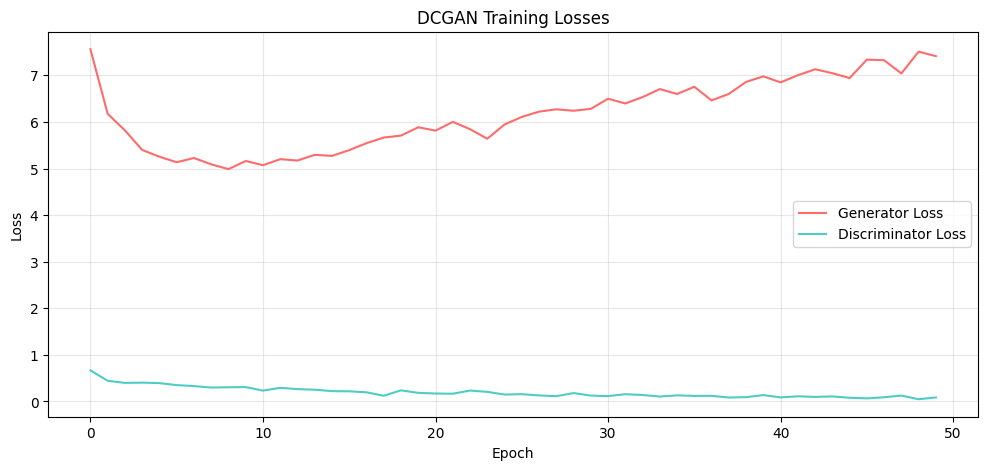

In [25]:
# Plot losses
plt.figure(figsize=(12, 5))
plt.plot(G_losses, label="Generator Loss", color="#ff6b6b")
plt.plot(D_losses, label="Discriminator Loss", color="#4ecdc4")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("dcgan_results/loss_plot.png", dpi=150)
plt.show()


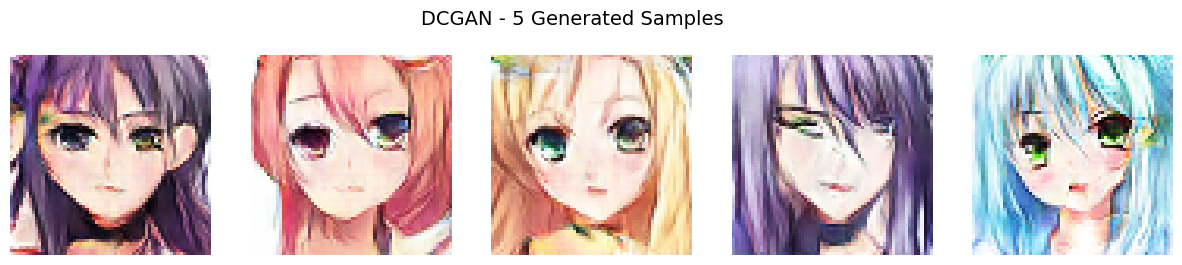

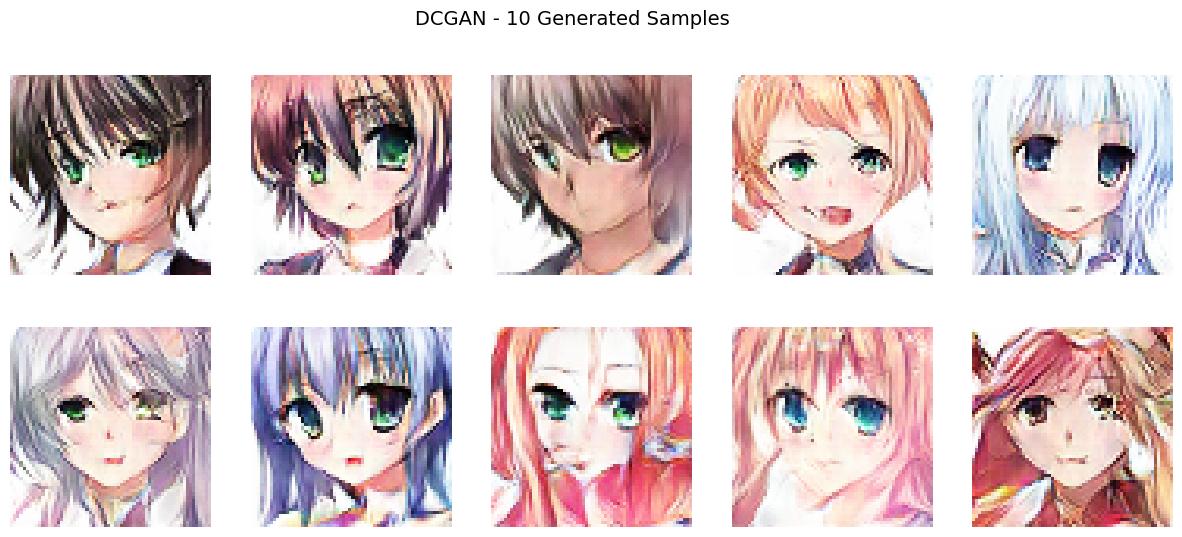

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

In [26]:
# Generate samples
Gen.eval()
with torch.no_grad():
    noise_5 = torch.randn(5, 100, 1, 1, device=device)
    samples_5 = Gen(noise_5).cpu()

    noise_10 = torch.randn(10, 100, 1, 1, device=device)
    samples_10 = Gen(noise_10).cpu()

# Show 5 samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("DCGAN - 5 Generated Samples", fontsize=14)
for idx, ax in enumerate(axes):
    img = samples_5[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.savefig("dcgan_results/samples_5.png", dpi=150)
plt.show()

# Show 10 samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("DCGAN - 10 Generated Samples", fontsize=14)
for idx, ax in enumerate(axes.flatten()):
    img = samples_10[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.savefig("dcgan_results/samples_10.png", dpi=150)
plt.show()

Gen.train()


**WGAN-GP**************


In [13]:
Gen_optimizer=torch.optim.Adam(Gen.parameters(),lr=0.0001,betas=(0.0,0.9))
Dis_optimizer=torch.optim.Adam(Dis.parameters(),lr=0.0001,betas=(0.0,0.9))

In [14]:
#gradient penalty
def gradient_penalty(Dis,real,fake,device):
    batch_size=real.size(0)
    alpha=torch.rand(batch_size,1,1,1,device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    interpolated = interpolated.float()  # ← add this

    score = Dis(interpolated)

    gradients = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True
    )[0]
    # Compute L2 norm of gradients
    gradients = gradients.view(batch_size, -1)  # ← flatten to (batch, C*H*W)

    grad_norm = gradients.norm(2, dim=1)

    # Compute gradient penalty
    gp = ((grad_norm - 1) ** 2).mean()

    return gp


In [20]:
import torchvision.utils as vutils
import os
os.makedirs("wgan_results", exist_ok=True)

num_epoch=30
G_losses=[]
D_losses=[]
img_list=[]
best_g_loss = float('inf')  # was 0, needs inf since you compare avg_g < best_g_loss
scaler=torch.amp.GradScaler('cuda')
print("Started WGAN-GP Training")
CRITIC_ITERATIONS = 3
LAMBDA = 10
best_d_balance = float('inf')

for i in range(num_epoch):
    g_loss_total = 0.0       # renamed: you were using g_loss_epoch but never defined it
    d_loss_total = 0.0       # renamed: same issue with d_loss_epoch
    num_batches = 0          # was never initialized

    for idx,(real_images,_) in enumerate(dataloader):
        
        real_images = real_images.to(device)  # ← add this

      
        for _ in range(CRITIC_ITERATIONS):
            
            Dis.zero_grad()

            noise = torch.randn(real_images.size(0), 100, 1, 1, device=device)
            fake_image = Gen(noise).detach()

            real_scores = Dis(real_images)
            fake_scores = Dis(fake_image)

            gp = gradient_penalty(Dis, real_images, fake_image, device)

            d_loss = fake_scores.mean() - real_scores.mean() + LAMBDA * gp
            d_loss.backward()
            Dis_optimizer.step()
        Gen.zero_grad()

        noise = torch.randn(real_images.size(0), 100, 1, 1, device=device)
        fake_image = Gen(noise)

        fake_scores = Dis(fake_image)
        g_loss = -fake_scores.mean()

        g_loss.backward()
        Gen_optimizer.step()



        

        g_loss_total += g_loss.item()
        d_loss_total += d_loss.item()
        num_batches += 1
    # Average losses
    avg_g = g_loss_total / num_batches
    avg_d = d_loss_total / num_batches
    G_losses.append(avg_g)
    D_losses.append(avg_d)
    print(f"Epoch [{i+1}/{num_epoch}]  Loss_D: {avg_d:.4f}  Loss_G: {avg_g:.4f}")  # was: epoch+1/num_epochs

    # Save best model
# Replace the "Save best model" block with:
    if abs(avg_d) < best_d_balance:
        
        best_d_balance = abs(avg_d)
        torch.save(Gen.state_dict(), "wgan_results/wgan-gp_generator_best.pth")
        torch.save(Dis.state_dict(), "wgan_results/wgan-gp_discriminator_best.pth")
    
print("WCGAN Training Complete!")

        


        





Started WGAN-GP Training
Epoch [1/30]  Loss_D: -8.9552  Loss_G: 18.5474
Epoch [2/30]  Loss_D: -8.6763  Loss_G: 18.1171
Epoch [3/30]  Loss_D: -8.4072  Loss_G: 18.1442
Epoch [4/30]  Loss_D: -8.1956  Loss_G: 18.0354
Epoch [5/30]  Loss_D: -8.0961  Loss_G: 18.6847
Epoch [6/30]  Loss_D: -7.9056  Loss_G: 18.9755
Epoch [7/30]  Loss_D: -7.8125  Loss_G: 18.6818
Epoch [8/30]  Loss_D: -7.7285  Loss_G: 19.1457
Epoch [9/30]  Loss_D: -7.6634  Loss_G: 21.0176
Epoch [10/30]  Loss_D: -7.6133  Loss_G: 21.1096
Epoch [11/30]  Loss_D: -7.4893  Loss_G: 20.8695
Epoch [12/30]  Loss_D: -7.5113  Loss_G: 21.1733
Epoch [13/30]  Loss_D: -7.4609  Loss_G: 21.3029
Epoch [14/30]  Loss_D: -7.4089  Loss_G: 21.5751
Epoch [15/30]  Loss_D: -7.3859  Loss_G: 22.7260
Epoch [16/30]  Loss_D: -7.3410  Loss_G: 23.3721
Epoch [17/30]  Loss_D: -7.3150  Loss_G: 23.7835
Epoch [18/30]  Loss_D: -7.2922  Loss_G: 23.4717
Epoch [19/30]  Loss_D: -7.3119  Loss_G: 24.2275
Epoch [20/30]  Loss_D: -7.2567  Loss_G: 24.0991
Epoch [21/30]  Loss_D: -

FileNotFoundError: [Errno 2] No such file or directory: 'dcgan_results/loss_plot.png'

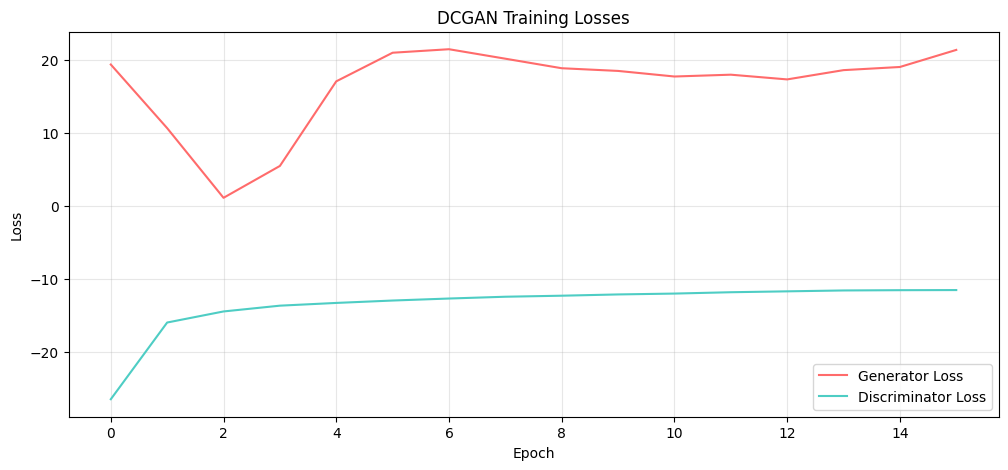

In [17]:
# Plot losses
plt.figure(figsize=(12, 5))
plt.plot(G_losses, label="Generator Loss", color="#ff6b6b")
plt.plot(D_losses, label="Discriminator Loss", color="#4ecdc4")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("dcgan_results/loss_plot.png", dpi=150)
plt.show()


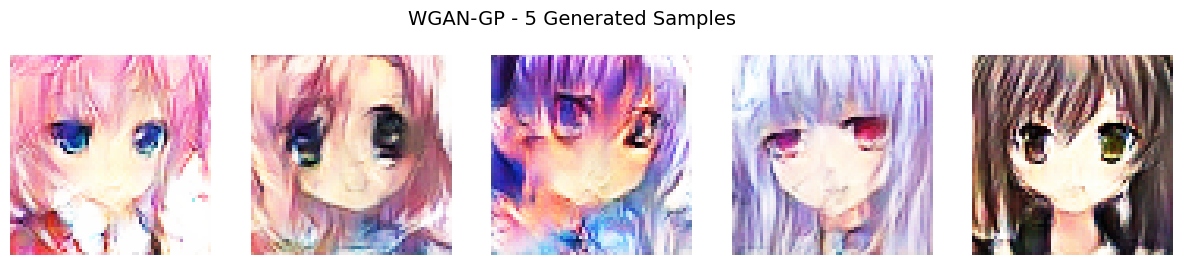

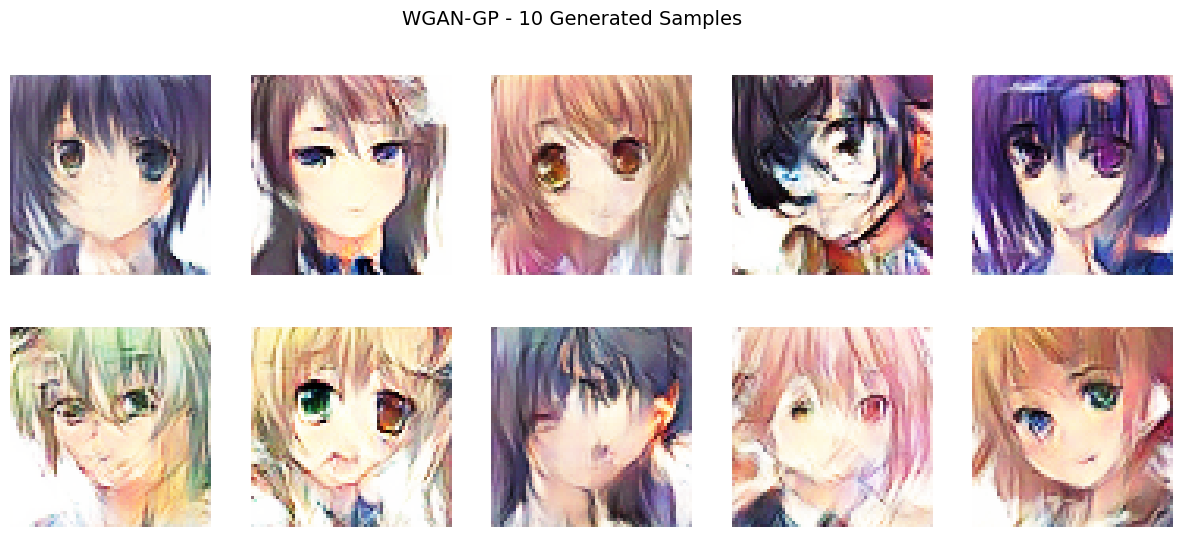

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

In [19]:
# Generate samples from WGAN-GP
Gen.eval()
with torch.no_grad():
    noise_5 = torch.randn(5, 100, 1, 1, device=device)
    samples_5 = Gen(noise_5).cpu()

    noise_10 = torch.randn(10, 100, 1, 1, device=device)
    samples_10 = Gen(noise_10).cpu()

# Show 5 samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("WGAN-GP - 5 Generated Samples", fontsize=14)
for idx, ax in enumerate(axes):
    img = samples_5[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.savefig("wgan_results/samples_5.png", dpi=150)
plt.show()

# Show 10 samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("WGAN-GP - 10 Generated Samples", fontsize=14)
for idx, ax in enumerate(axes.flatten()):
    img = samples_10[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.savefig("wgan_results/samples_10.png", dpi=150)
plt.show()

Gen.train()


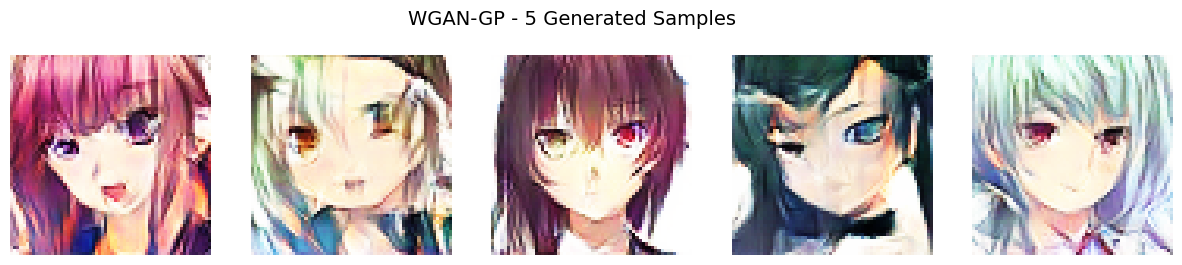

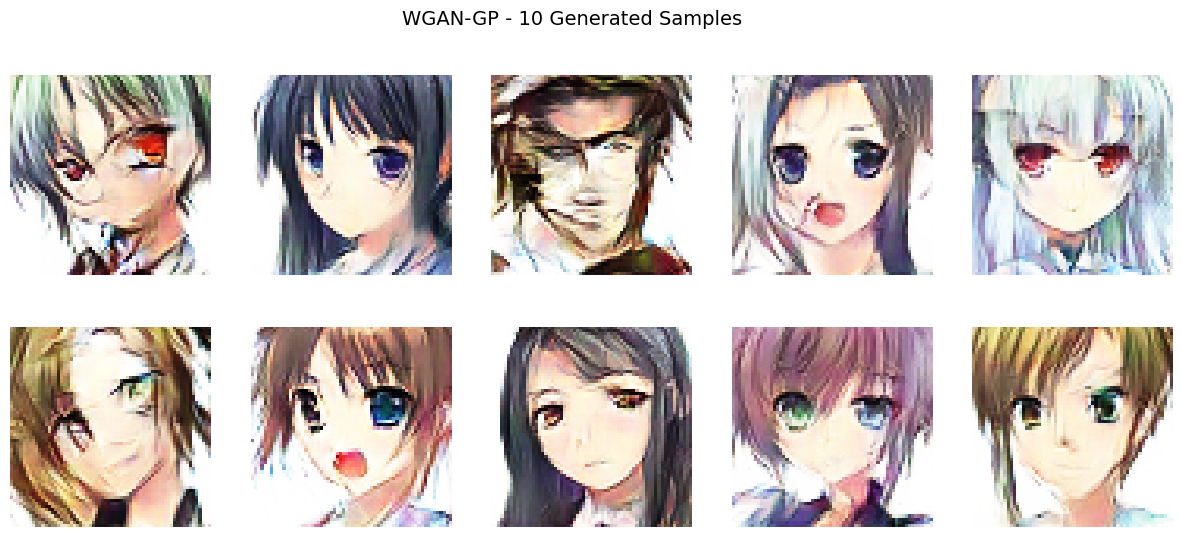

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

In [21]:
# Generate samples from WGAN-GP
Gen.eval()
with torch.no_grad():
    noise_5 = torch.randn(5, 100, 1, 1, device=device)
    samples_5 = Gen(noise_5).cpu()

    noise_10 = torch.randn(10, 100, 1, 1, device=device)
    samples_10 = Gen(noise_10).cpu()

# Show 5 samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("WGAN-GP - 5 Generated Samples", fontsize=14)
for idx, ax in enumerate(axes):
    img = samples_5[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.savefig("wgan_results/samples_5.png", dpi=150)
plt.show()

# Show 10 samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("WGAN-GP - 10 Generated Samples", fontsize=14)
for idx, ax in enumerate(axes.flatten()):
    img = samples_10[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.savefig("wgan_results/samples_10.png", dpi=150)
plt.show()

Gen.train()
